In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal

import math
from sklearn.decomposition import PCA
!pip install elephant
from elephant.gpfa import GPFA

import quantities as pq
from elephant.spike_train_generation import inhomogeneous_poisson_process
import neo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.6/644.6 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.2/101.2 kB 11.4 MB/s eta 0:00:00


In [2]:
def generate_spiketrains(instantaneous_rates, num_trials, timestep):
    """
    Parameters
    ----------
    instantaneous_rates : np.ndarray
        Array containing time series.
    timestep :
        Sample period.
    num_steps : int
        Number of timesteps -> max_time = timestep*(num_steps-1).

    Returns
    -------
    spiketrains : list of neo.SpikeTrains
        List containing spiketrains of inhomogeneous Poisson
        processes based on given instantaneous rates.

    """

    spiketrains = []
    for _ in range(num_trials):
        spiketrains_per_trial = []
        for inst_rate in instantaneous_rates:
            anasig_inst_rate = neo.AnalogSignal(inst_rate, sampling_rate=1/timestep, units=pq.Hz)
            spiketrains_per_trial.append(inhomogeneous_poisson_process(anasig_inst_rate))
        spiketrains.append(spiketrains_per_trial)

    return spiketrains

In [3]:
dtype = torch.float
# Check whether GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [4]:
dat_dir = '/content/drive/MyDrive/Project/PlasticityDecoding/data/EndtoEnd'
SPK = []
ptype = []
for rnum in range(0, 11):
    SPK.append(np.load(dat_dir + f'/Spk_an_wn_{rnum}.npy'))
    ptype.append(np.load(dat_dir + f'/Ptype_an_wn_{rnum}.npy'))

SPK = np.concatenate(SPK, axis=0)
ptype = np.concatenate(ptype, axis=0)

num_trials = 60
timestep = 1 * pq.ms

# specify fitting parameters
bin_size = 500 * pq.ms #ms
latent_dimensionality = 2
gpfa_dim = GPFA(bin_size=bin_size, x_dim=latent_dimensionality)

spiketrains_ptype = []
for ii in np.unique(ptype):
    # generate spike trains
    spiketrains_ptype.append(generate_spiketrains(1000 * SPK[np.argwhere(ptype == ii).flatten(),:][:,:], num_trials, timestep))
    print(ii)
trajectories_ptype = []
for ii in np.unique(ptype):
    gpfa_dim.fit(spiketrains_ptype[int(ii)])
    trajectories_ptype.append(gpfa_dim.transform(spiketrains_ptype[int(ii)]))

0.0
1.0
2.0
3.0
Initializing parameters using factor analysis...

Fitting GPFA model...
Initializing parameters using factor analysis...

Fitting GPFA model...
Initializing parameters using factor analysis...

Fitting GPFA model...
Initializing parameters using factor analysis...

Fitting GPFA model...


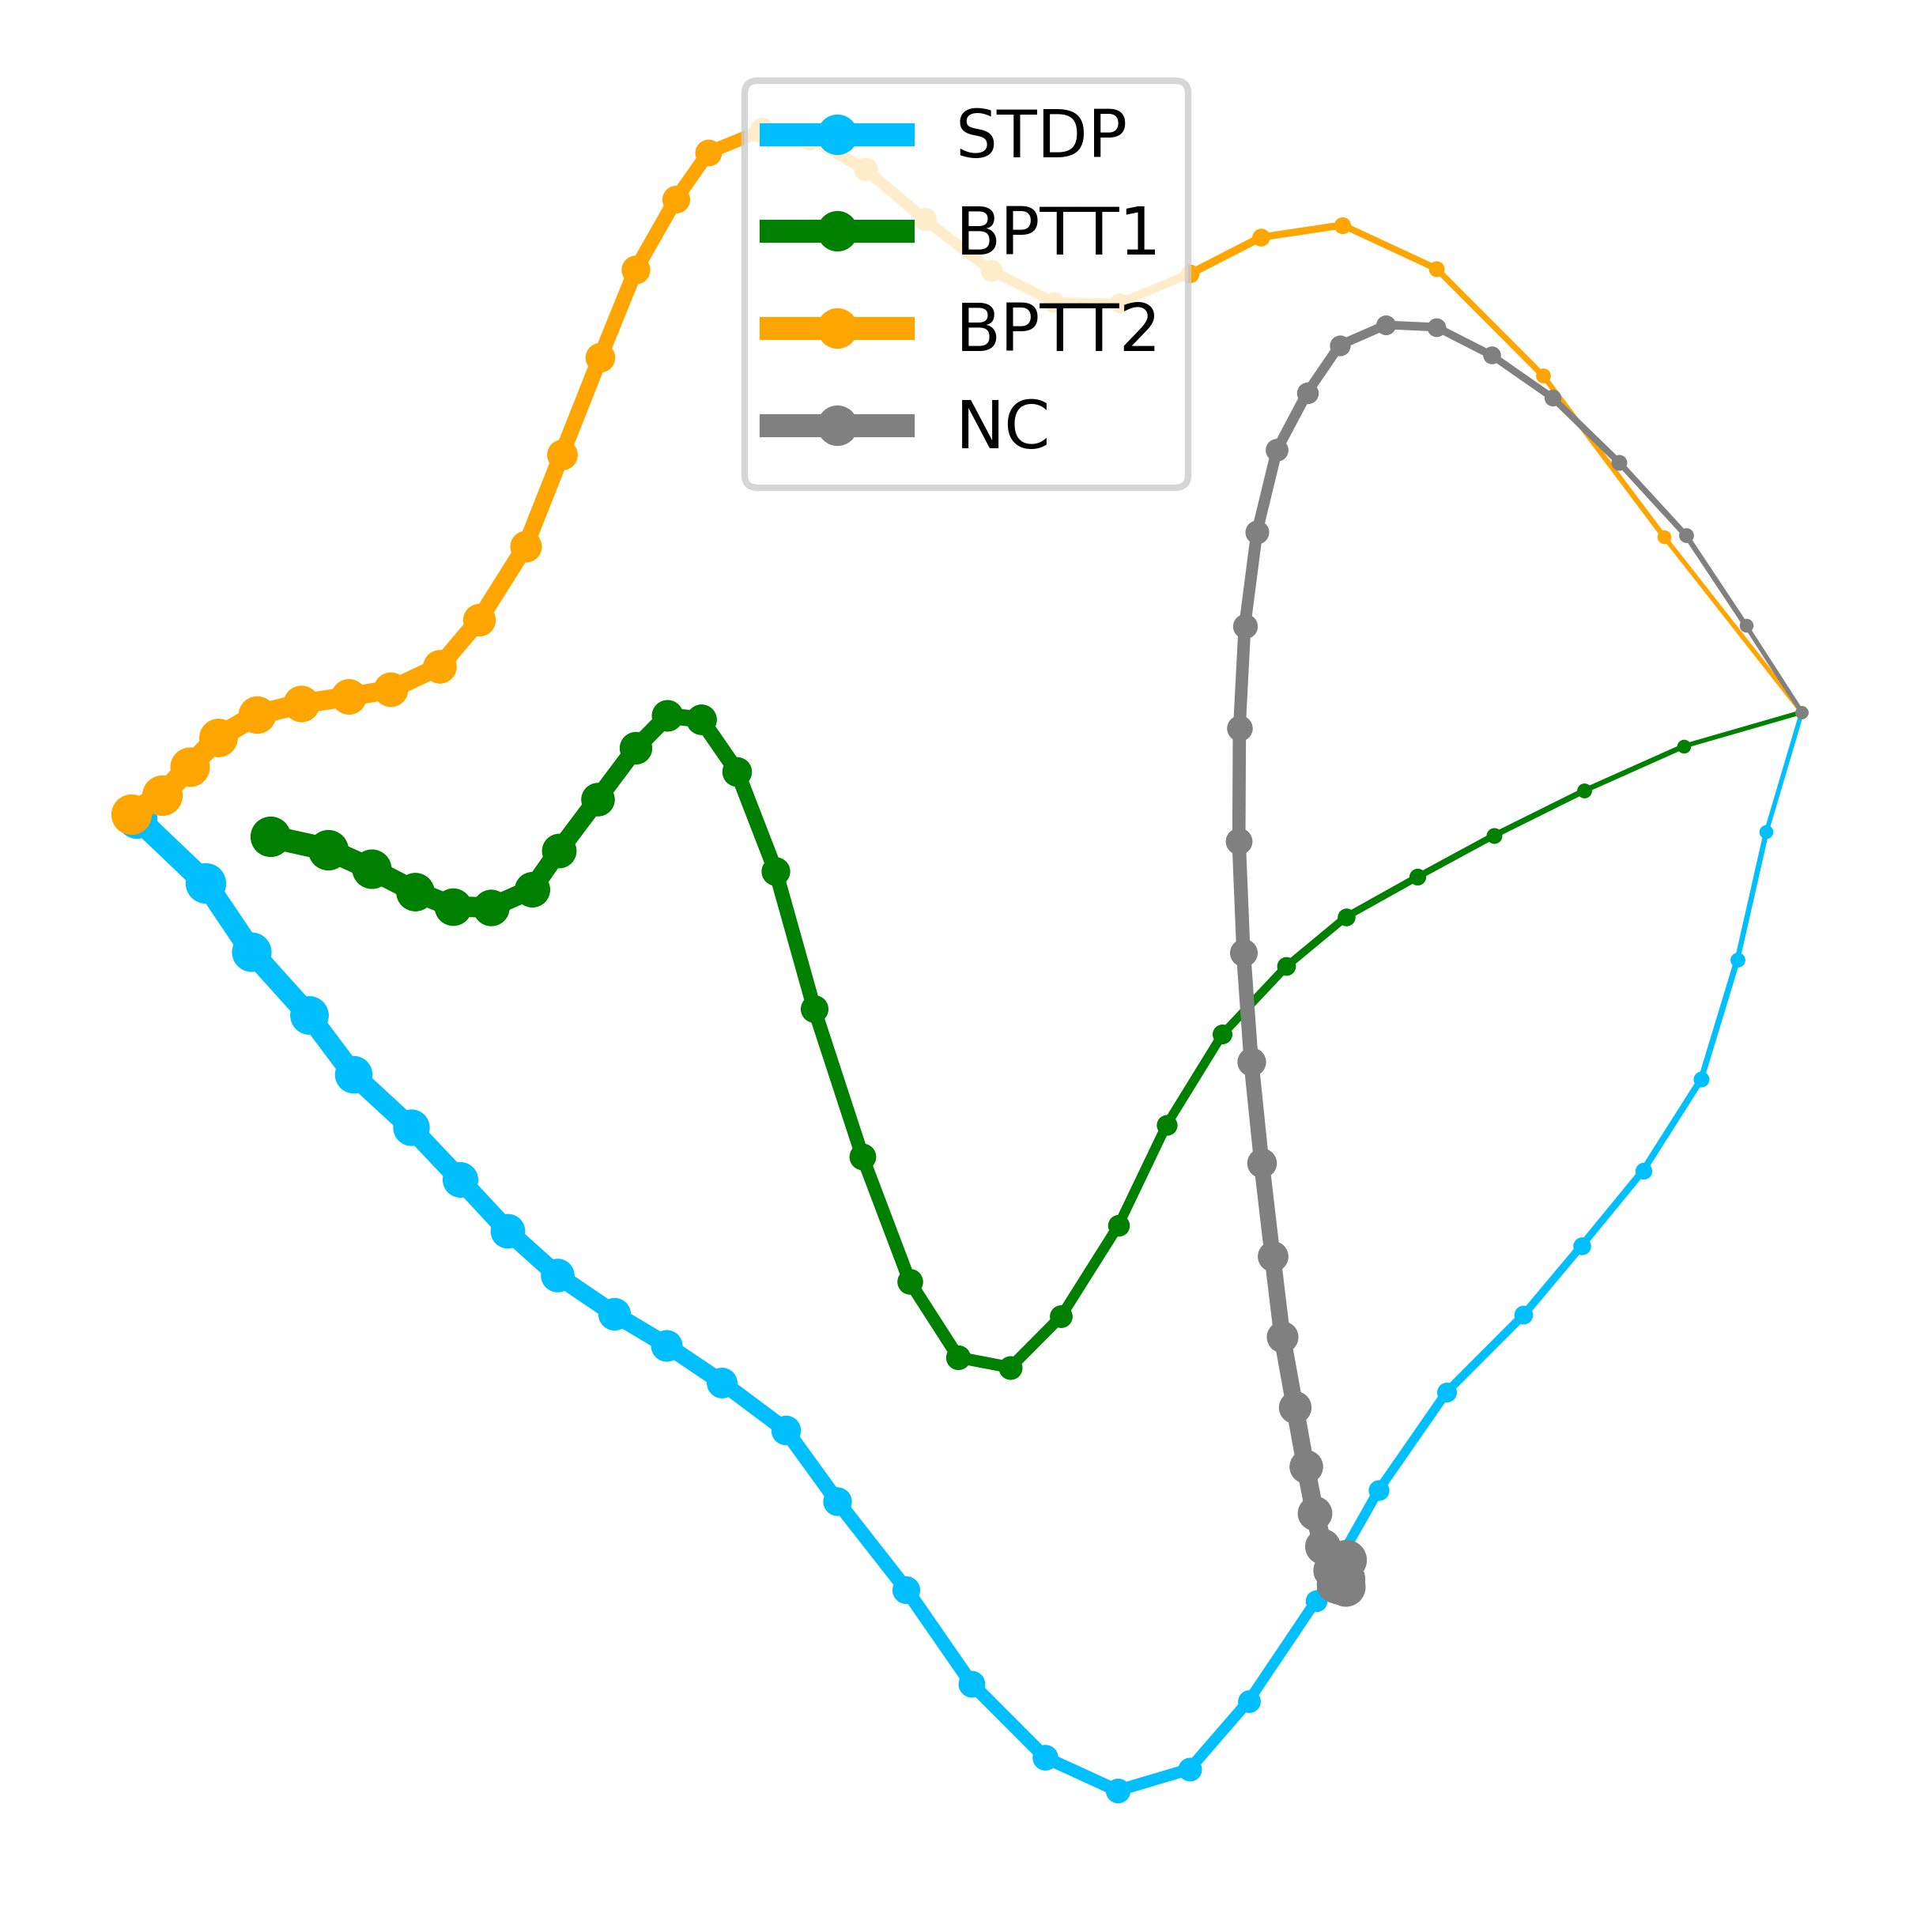

In [8]:
color_list = ['deepskyblue', 'green', 'orange', 'gray']
label_list = ['STDP', 'BPTT1', 'BPTT2', 'NC']
ax = plt.figure(figsize=(5,5),dpi=600)
for ii in range(0, 4):
    trajectories0 = []
    for jj in range(1, num_trials):
        trajectories0.append(trajectories_ptype[ii][jj][:])
    trajectories0 = np.array(trajectories0)
    for kk in range(0, np.size(trajectories0, axis=2) - 1):
        if kk == np.size(trajectories0, axis=2) - 2:
            plt.plot(trajectories0[:,0,kk : kk + 2].mean(axis=0) - trajectories0[:,0,0].mean(axis=0),
                    trajectories0[:,1,kk : kk + 2].mean(axis=0) - trajectories0[:,1,0].mean(axis=0),
                    'o-',markersize=(kk + 1) * 0.15 + 0.8,linewidth=(kk + 1) * 0.1 + 0.6,color = color_list[ii],label = label_list[ii])
        else:
            plt.plot(trajectories0[:,0,kk : kk + 2].mean(axis=0) - trajectories0[:,0,0].mean(axis=0),
                    trajectories0[:,1,kk : kk + 2].mean(axis=0) - trajectories0[:,1,0].mean(axis=0),
                    'o-',markersize=(kk + 1) * 0.15 + 0.8,linewidth=(kk + 1) * 0.1 + 0.6,color = color_list[ii])
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(loc='upper center')
sns.despine()
# plt.xlim([0, -55])
plt.axis('off')
plt.show()